In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from statsmodels.stats.outliers_influence import variance_inflation_factor
from ydata_profiling import ProfileReport
from ydata_profiling.config import Settings
import warnings
warnings.filterwarnings('ignore')

# 시각화할때 한글깨짐 방지용 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

In [2]:
# 데이터 로드
DATA_PATH = "../data/processed/refined_data.csv"
df = pd.read_csv(DATA_PATH)
print(f"데이터 로딩완료: {DATA_PATH}")
print("컬럼 목록:", df.columns.tolist())

데이터 로딩완료: ../data/processed/refined_data.csv
컬럼 목록: ['텍스트', '라벨', '검색어', '출처', '불용어_제거', '문장_길이', '단어_개수', '단어_평균길이', '어휘_다양성', '단어_밀도', '특문_개수']


In [3]:
'''
애초에 단어개수와 문장길이의 연산으로 만든 피처(종속관계)이기때문에
다중공선성이 높은 것 나옴
'''
print("다중공선성(VIF) 검증 결과")
features = ['문장_길이', '단어_개수', '단어_평균길이', '어휘_다양성', '단어_밀도', '특문_개수']
X = df[features].dropna()

vif_df = pd.DataFrame()
vif_df["피처"] = features
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(features))]

vif_df.sort_values(by="VIF", ascending=False)

다중공선성(VIF) 검증 결과


,피처,VIF
1,단어_개수,349.542554
0,문장_길이,338.839395
4,단어_밀도,95.590152
2,단어_평균길이,73.505034
3,어휘_다양성,42.042712
5,특문_개수,12.674509


In [4]:
'''
EDA 리포트 생성
결측치 X
'''
output_path = "../발표자료리소스/eda_report.html"
# 리포트 생성 설정 
profile = ProfileReport(df, title="LLM 판별 데이터 EDA 리포트", explorative=True)
profile.to_file(output_path)
print(f"리포트 생성 완료: {output_path}")

Summarize dataset:  72%|███████▏  | 13/18 [00:34<00:28,  5.74s/it, Calculate auto correlation]d:\ml_research_llm\.venv\lib\site-packages\ydata_profiling\model\correlations.py:66: UserWarning: There was an attempt to calculate the auto correlation, but this failed.
To hide this warning, disable the calculation
(using `df.profile_report(correlations={"auto": {"calculate": False}})`
If this is problematic for your use case, please report this as an issue:
https://github.com/ydataai/ydata-profiling/issues
(include the error message: 'could not convert string to float: 'Phones and driving'')
  warnings.warn(
Summarize dataset:  26%|██▌       | 14/54 [00:34<03:49,  5.74s/it, scatter 문장_길이, 문장_길이]      d:\ml_research_llm\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from current font.
  plt.savefig(
d:\ml_research_llm\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: UserWarning: Glyph 51109 (\N{H

리포트 생성 완료: ../발표자료리소스/eda_report.html


유사 변수(단어 수 및 밀도) 분포 시각화


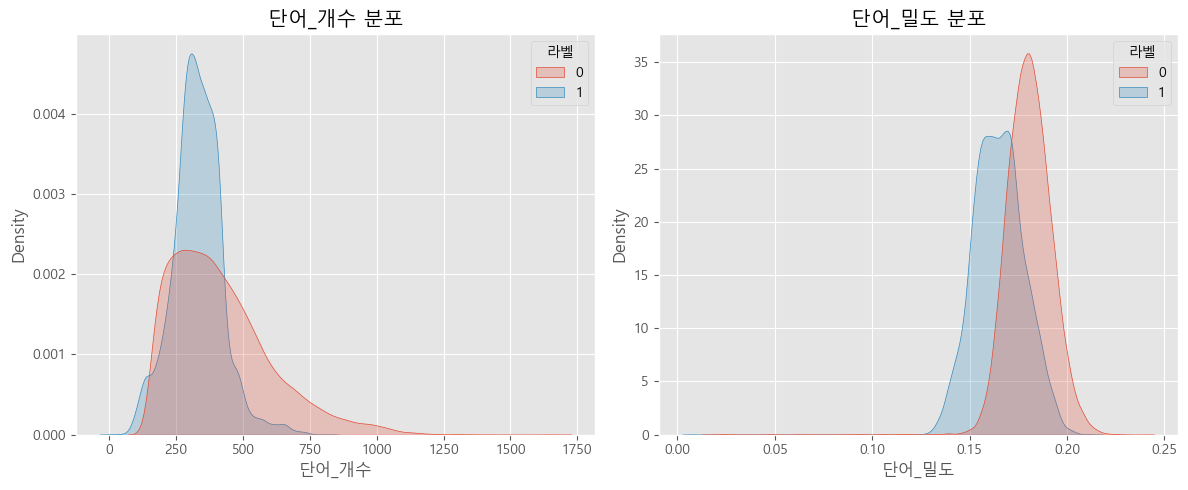

In [ ]:
'''
사람이 쓴글과 AI가 쓴글을 한가지 컬럼을 두고 비교
'''
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

print("유사 변수(단어 수 및 밀도) 분포 시각화")
plt.style.use('ggplot')
plt.rc('font', family='Malgun Gothic')

features_to_plot = ['단어_개수', '단어_밀도']
plt.figure(figsize=(12, 5))

for i, col in enumerate(features_to_plot, 1):
    plt.subplot(1, len(features_to_plot), i)
    sns.kdeplot(data=df, x=col, hue='라벨', fill=True, common_norm=False)
    plt.title(f'{col} 분포')

plt.tight_layout()
plt.show()
